# Análisis Exploratorio de las imágenes

### Importación de librerías

In [10]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('grayscale')

ruta_datos = Path("../../data/PPMI")

#### Extracción de un sujeto

In [11]:
def cargar_volumen_dicom(ruta_carpeta_serie):
    archivos = list(Path(ruta_carpeta_serie).glob("*.dcm"))
    if not archivos:
        return None, None
        
    cortes = []
    for archivo in archivos:
        try:
            corte = pydicom.dcmread(archivo)
            if hasattr(corte, 'PixelData'):
                cortes.append(corte)
        except:
            pass
            
    if not cortes:
        return None, None

    def obtener_posicion_z(corte):
        if hasattr(corte, 'ImagePositionPatient'):
            return float(corte.ImagePositionPatient[2])
        elif hasattr(corte, 'SliceLocation'):
            return float(corte.SliceLocation)
        elif hasattr(corte, 'InstanceNumber'):
            return float(corte.InstanceNumber)
        return 0.0

    cortes.sort(key=obtener_posicion_z)
    
    espaciado_pixel = cortes[0].PixelSpacing if hasattr(cortes[0], 'PixelSpacing') else [1.0, 1.0]
    grosor_corte = cortes[0].SliceThickness if hasattr(cortes[0], 'SliceThickness') else 1.0
    
    espaciado_3d = (float(grosor_corte), float(espaciado_pixel[0]), float(espaciado_pixel[1]))
    
    try:
        volumen = np.stack([corte.pixel_array for corte in cortes])
    except ValueError:
        return None, None
        
    return volumen, espaciado_3d

carpetas_sujetos = [d for d in ruta_datos.iterdir() if d.is_dir()]
sujeto_prueba = carpetas_sujetos[0]

carpetas_internas = [x[0] for x in os.walk(sujeto_prueba) if any(f.endswith('.dcm') for f in x[2])]
ruta_serie_prueba = carpetas_internas[0]

volumen_3d, espaciado = cargar_volumen_dicom(ruta_serie_prueba)

if volumen_3d is not None:
    print(f"Sujeto cargado: {sujeto_prueba.name}")
    print(f"Dimensiones de la matriz 3D: {volumen_3d.shape}")
    print(f"Resolucion fisica (Z, X, Y) en mm: {espaciado}")
else:
    print(f"No se pudo cargar un volumen valido para el sujeto {sujeto_prueba.name}")

Sujeto cargado: 100001
Dimensiones de la matriz 3D: (192, 256, 256)
Resolucion fisica (Z, X, Y) en mm: (1.0, 1.0, 1.0)


### Imágenes centrales del sujeto

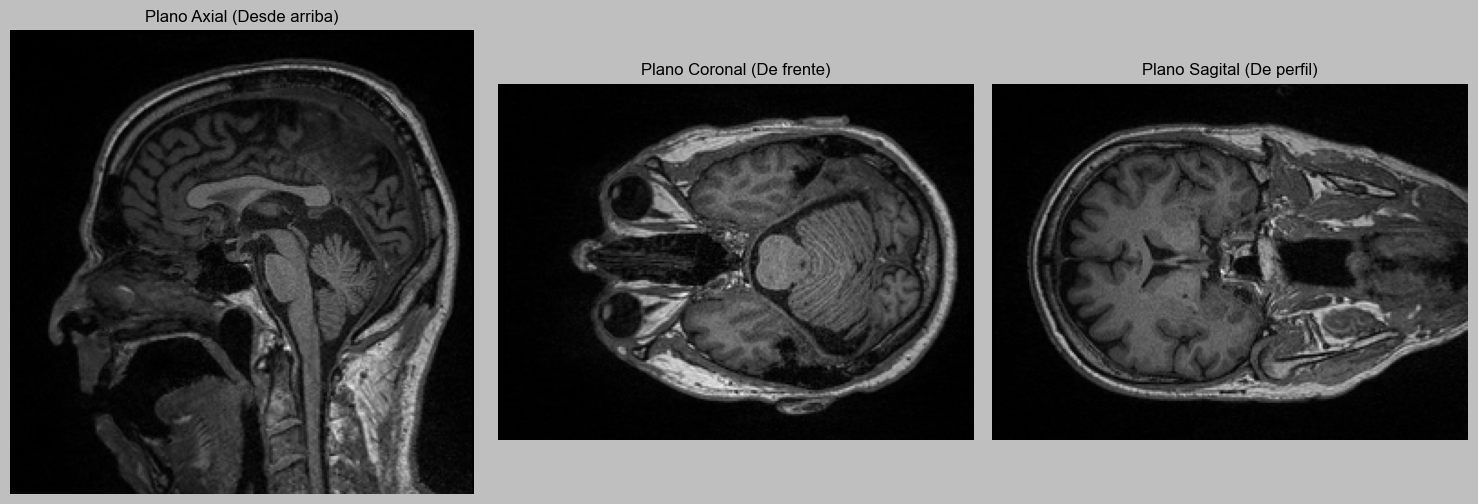

In [12]:
centro_z = volumen_3d.shape[0] // 2
centro_y = volumen_3d.shape[1] // 2
centro_x = volumen_3d.shape[2] // 2

corte_axial = volumen_3d[centro_z, :, :]
corte_coronal = volumen_3d[:, centro_y, :]
corte_sagital = volumen_3d[:, :, centro_x]

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

ejes[0].imshow(corte_axial)
ejes[0].set_title("Plano Axial (Desde arriba)")
ejes[0].axis('off')

ejes[1].imshow(corte_coronal)
ejes[1].set_title("Plano Coronal (De frente)")
ejes[1].axis('off')

ejes[2].imshow(corte_sagital)
ejes[2].set_title("Plano Sagital (De perfil)")
ejes[2].axis('off')

plt.tight_layout()
plt.show()

#### Intensidad de los pixeles

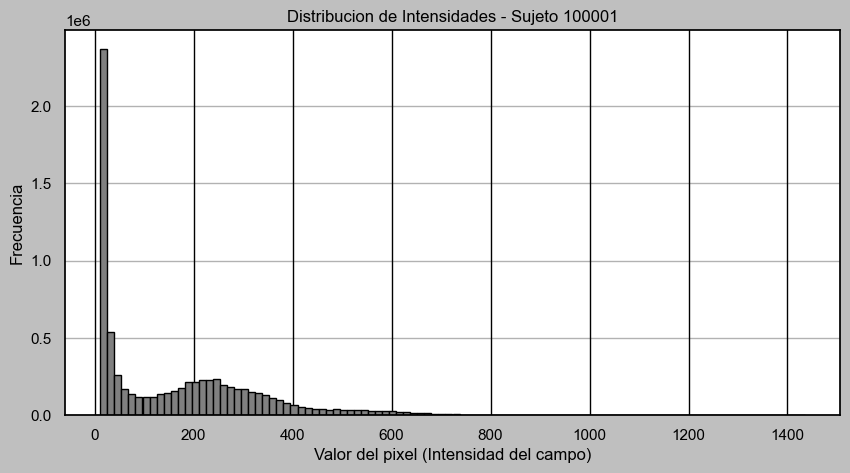

Intensidad minima: 11
Intensidad maxima: 1435
Intensidad media: 165.11


In [13]:
pixeles_cerebro = volumen_3d[volumen_3d > 10]

plt.figure(figsize=(10, 5))
plt.hist(pixeles_cerebro.flatten(), bins=100, color='gray')
plt.title(f"Distribucion de Intensidades - Sujeto {sujeto_prueba.name}")
plt.xlabel("Valor del pixel (Intensidad del campo)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Intensidad minima: {np.min(pixeles_cerebro)}")
print(f"Intensidad maxima: {np.max(pixeles_cerebro)}")
print(f"Intensidad media: {np.mean(pixeles_cerebro):.2f}")

#### Dimensiones y resoluciones de las imagenes

[INFO] Iniciando auditoría estructural de 1743 pacientes...


Procesando Volúmenes DICOM: 100%|██████████| 1743/1743 [16:27<00:00,  1.77it/s]



[OK] Auditoría completada. Generando visualizaciones...


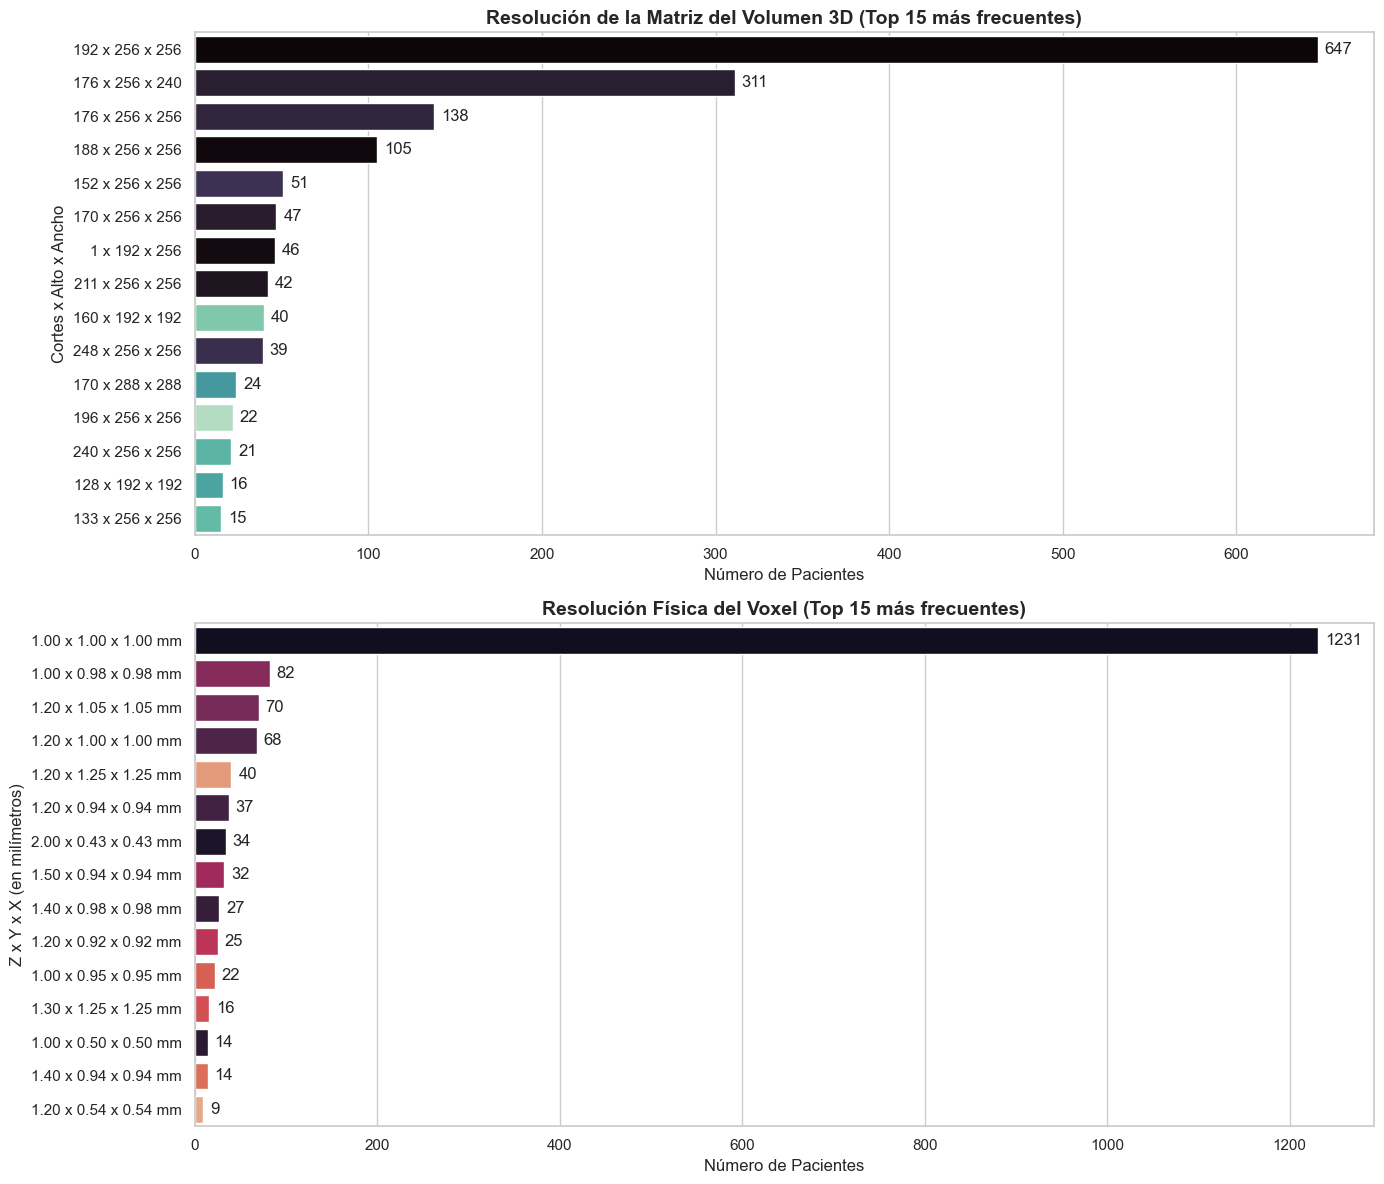

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid")

datos_auditoria = []

print(f"[INFO] Iniciando auditoría estructural de {len(carpetas_sujetos)} pacientes...")

for paciente in tqdm(carpetas_sujetos, desc="Procesando Volúmenes DICOM"):
    carpetas_dicom = [x[0] for x in os.walk(paciente) if any(f.endswith('.dcm') for f in x[2])]
    
    if carpetas_dicom:
        volumen, espaciado = cargar_volumen_dicom(carpetas_dicom[0])
        
        if volumen is not None:
            dimension_str = f"{volumen.shape[0]} x {volumen.shape[1]} x {volumen.shape[2]}"
            espaciado_str = f"{espaciado[0]:.2f} x {espaciado[1]:.2f} x {espaciado[2]:.2f} mm"
            
            datos_auditoria.append({
                'Dimensiones (Z x Y x X)': dimension_str,
                'Espaciado Voxel (mm)': espaciado_str
            })

df_auditoria = pd.DataFrame(datos_auditoria)
print("\n[OK] Auditoría completada. Generando visualizaciones...")

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

orden_dim = df_auditoria['Dimensiones (Z x Y x X)'].value_counts().index[:15]

ax1 = sns.countplot(ax=axes[0], data=df_auditoria, y='Dimensiones (Z x Y x X)', 
                    order=orden_dim, hue='Dimensiones (Z x Y x X)', palette='mako', legend=False)
axes[0].set_title('Resolución de la Matriz del Volumen 3D (Top 15 más frecuentes)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Número de Pacientes')
axes[0].set_ylabel('Cortes x Alto x Ancho')

for p in ax1.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        ax1.annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points')

orden_esp = df_auditoria['Espaciado Voxel (mm)'].value_counts().index[:15]

ax2 = sns.countplot(ax=axes[1], data=df_auditoria, y='Espaciado Voxel (mm)', 
                    order=orden_esp, hue='Espaciado Voxel (mm)', palette='rocket', legend=False)
axes[1].set_title('Resolución Física del Voxel (Top 15 más frecuentes)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Número de Pacientes')
axes[1].set_ylabel('Z x Y x X (en milímetros)')

for p in ax2.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        ax2.annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()